In [ ]:
# ============================================
# Import Libraries
# ============================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.model_selection import train_test_split

from xgboost import XGBRegressor

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [ ]:
DATA_PATH="/content"

print(os.listdir(DATA_PATH))

['.config', 'RUL_FD001.txt', 'train_FD002.txt', 'RUL_FD002.txt', 'train_FD001.txt', 'test_FD004.txt', 'train_FD004.txt', 'RUL_FD004.txt', 'test_FD002.txt', 'train_FD003.txt', 'test_FD001.txt', 'RUL_FD003.txt', '.ipynb_checkpoints', 'test_FD003.txt', 'sample_data']


In [ ]:
# ============================================
# Load All NASA Datasets
# ============================================

column_names = (
    ["engine_id","cycle"] +
    [f"op_setting_{i}" for i in range(1,4)] +
    [f"sensor_{i}" for i in range(1,22)]
)

datasets={}

for fd in ["FD001","FD002","FD003","FD004"]:

    train=pd.read_csv(
        f"{DATA_PATH}/train_{fd}.txt",
        sep=r"\s+",
        header=None
    )

    test=pd.read_csv(
        f"{DATA_PATH}/test_{fd}.txt",
        sep=r"\s+",
        header=None
    )

    rul=pd.read_csv(
        f"{DATA_PATH}/RUL_{fd}.txt",
        header=None
    )

    train.columns=column_names
    test.columns=column_names

    datasets[fd]={
        "train":train,
        "test":test,
        "rul":rul
    }

print("All Datasets Loaded Successfully")

All Datasets Loaded Successfully


In [ ]:
for fd in datasets:

    print("="*60)

    print(fd)

    print("="*60)

    print("Train :",datasets[fd]["train"].shape)

    print("Test  :",datasets[fd]["test"].shape)

    print("RUL   :",datasets[fd]["rul"].shape)

    print()

FD001
Train : (20631, 26)
Test  : (13096, 26)
RUL   : (100, 1)

FD002
Train : (53759, 26)
Test  : (33991, 26)
RUL   : (259, 1)

FD003
Train : (24720, 26)
Test  : (16596, 26)
RUL   : (100, 1)

FD004
Train : (61249, 26)
Test  : (41214, 26)
RUL   : (248, 1)



In [ ]:
# ============================================
# Generate RUL
# ============================================

for fd in datasets:

    train=datasets[fd]["train"]

    max_cycle=train.groupby(
        "engine_id"
    )["cycle"].max()

    train["max_cycle"]=train["engine_id"].map(max_cycle)

    train["RUL"]=(
        train["max_cycle"]-
        train["cycle"]
    )

    datasets[fd]["train"]=train

print("RUL Generated")

RUL Generated


In [ ]:
selected_features=[

"op_setting_1",
"op_setting_2",
"op_setting_3",

"sensor_2",
"sensor_3",
"sensor_4",

"sensor_7",
"sensor_8",
"sensor_9",

"sensor_11",
"sensor_12",
"sensor_13",

"sensor_14",
"sensor_15",

"sensor_17",

"sensor_20",
"sensor_21"

]

print(selected_features)

['op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [ ]:
MAX_RUL=125

for fd in datasets:

    datasets[fd]["train"]["RUL"]=datasets[
        fd
    ]["train"]["RUL"].clip(
        upper=MAX_RUL
    )

print("RUL Capping Completed")

RUL Capping Completed


In [ ]:
prepared_data={}

for fd in datasets:

    train=datasets[fd]["train"]

    X=train[selected_features]

    y=train["RUL"]

    prepared_data[fd]={
        "X":X,
        "y":y
    }

print("Training Data Prepared")

Training Data Prepared


In [ ]:
scaled_data={}

for fd in prepared_data:

    scaler=StandardScaler()

    X=scaler.fit_transform(
        prepared_data[fd]["X"]
    )

    y=prepared_data[fd]["y"]

    scaled_data[fd]={
        "X":X,
        "y":y,
        "scaler":scaler
    }

print("Scaling Completed")

Scaling Completed


In [ ]:
for fd in scaled_data:

    print("="*60)

    print(fd)

    print("="*60)

    print("Features :",scaled_data[fd]["X"].shape)

    print("Target   :",scaled_data[fd]["y"].shape)

    print()

FD001
Features : (20631, 17)
Target   : (20631,)

FD002
Features : (53759, 17)
Target   : (53759,)

FD003
Features : (24720, 17)
Target   : (24720,)

FD004
Features : (61249, 17)
Target   : (61249,)



In [ ]:
# ============================================
# Prepare Official Test Data
# ============================================

test_data = {}

for fd in datasets:

    test = datasets[fd]["test"].copy()

    X_test = test[selected_features]

    X_test = scaled_data[fd]["scaler"].transform(X_test)

    test_data[fd] = X_test

print("Official Test Data Prepared")

Official Test Data Prepared


In [ ]:
# ============================================
# Official RUL Labels
# ============================================

true_rul = {}

for fd in datasets:

    true_rul[fd] = datasets[fd]["rul"][0].values

print("Official RUL Loaded")

Official RUL Loaded


In [ ]:
# ============================================
# Random Forest
# ============================================

def train_random_forest(X_train, y_train):

    model = RandomForestRegressor(

        n_estimators=500,

        max_depth=20,

        min_samples_leaf=2,

        random_state=42,

        n_jobs=-1

    )

    model.fit(X_train, y_train)

    return model

print("Random Forest Ready")

Random Forest Ready


In [ ]:
# ============================================
# Gradient Boosting
# ============================================

def train_gradient_boosting(X_train, y_train):

    model = GradientBoostingRegressor(

        n_estimators=500,

        learning_rate=0.03,

        max_depth=5,

        random_state=42

    )

    model.fit(X_train, y_train)

    return model

print("Gradient Boosting Ready")

Gradient Boosting Ready


In [ ]:
# ============================================
# XGBoost
# ============================================

def train_xgboost(X_train, y_train):

    model = XGBRegressor(

        n_estimators=500,

        learning_rate=0.03,

        max_depth=6,

        subsample=0.8,

        colsample_bytree=0.8,

        objective="reg:squarederror",

        random_state=42,

        n_jobs=-1

    )

    model.fit(X_train, y_train)

    return model

print("XGBoost Ready")

XGBoost Ready


In [ ]:
# ============================================
# Evaluation
# ============================================

def evaluate(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    r2 = r2_score(y_true, y_pred)

    return mae, rmse, r2

print("Evaluation Ready")

Evaluation Ready


In [ ]:
# ============================================
# Train and Evaluate (Official NASA Protocol)
# ============================================

comparison = []

trained_models = {}

models = {

    "Random Forest": train_random_forest,

    "Gradient Boosting": train_gradient_boosting,

    "XGBoost": train_xgboost

}

for fd in scaled_data:

    X_train = scaled_data[fd]["X"]

    y_train = scaled_data[fd]["y"]

    X_test = test_data[fd]

    y_true = true_rul[fd]

    # ⭐ Test dataframe
    test_df = datasets[fd]["test"].copy()

    # ⭐ Last cycle index of every engine
    last_index = test_df.groupby("engine_id").tail(1).index

    trained_models[fd] = {}

    for name, trainer in models.items():

        model = trainer(X_train, y_train)

        prediction = model.predict(X_test)

        # ⭐ Sirf last cycle prediction
        prediction = prediction[last_index]

        mae, rmse, r2 = evaluate(y_true, prediction)

        trained_models[fd][name] = {

            "model": model,

            "prediction": prediction

        }

        comparison.append({

            "Dataset": fd,

            "Model": name,

            "MAE": mae,

            "RMSE": rmse,

            "R2": r2

        })

print("Training Finished")

Training Finished


In [ ]:
comparison = pd.DataFrame(comparison)

comparison

,Dataset,Model,MAE,RMSE,R2
0,FD001,Random Forest,13.164105,18.095250,0.810386
1,FD001,Gradient Boosting,13.266934,18.245306,0.807229
2,FD001,XGBoost,13.077686,18.131279,0.809631
3,FD002,Random Forest,20.597506,29.131832,0.706564
4,FD002,Gradient Boosting,20.746938,29.476629,0.699577
5,FD002,XGBoost,20.565353,29.090670,0.707393
6,FD003,Random Forest,16.083574,21.180206,0.738211
7,FD003,Gradient Boosting,16.504185,22.304870,0.709671
8,FD003,XGBoost,16.253927,21.947734,0.718894
9,FD004,Random Forest,23.100669,30.517750,0.686720


In [ ]:
# ============================================
# Save Trained Models
# ============================================

import joblib
import os

SAVE_DIR = "Saved_Models"

os.makedirs(SAVE_DIR, exist_ok=True)

for fd in trained_models:

    for model_name in trained_models[fd]:

        filename = f"{SAVE_DIR}/{fd}_{model_name.replace(' ','_')}.pkl"

        joblib.dump(

            trained_models[fd][model_name]["model"],

            filename

        )

print("All Models Saved Successfully")

All Models Saved Successfully


In [ ]:
# ============================================
# Load Saved Models
# ============================================

import joblib

loaded_models = {}

for fd in ["FD001","FD002","FD003","FD004"]:

    loaded_models[fd] = {}

    for model in [

        "Random_Forest",

        "Gradient_Boosting",

        "XGBoost"

    ]:

        loaded_models[fd][model] = joblib.load(

            f"Saved_Models/{fd}_{model}.pkl"

        )

print("All Models Loaded Successfully")

All Models Loaded Successfully


In [ ]:
# ============================================
# Best Model for Each Dataset
# ============================================

best_models = comparison.loc[
    comparison.groupby("Dataset")["RMSE"].idxmin()
]

best_models = best_models.reset_index(drop=True)

best_models

,Dataset,Model,MAE,RMSE,R2
0,FD001,Random Forest,13.164105,18.095250,0.810386
1,FD002,XGBoost,20.565353,29.090670,0.707393
2,FD003,Random Forest,16.083574,21.180206,0.738211
3,FD004,Random Forest,23.100669,30.517750,0.686720


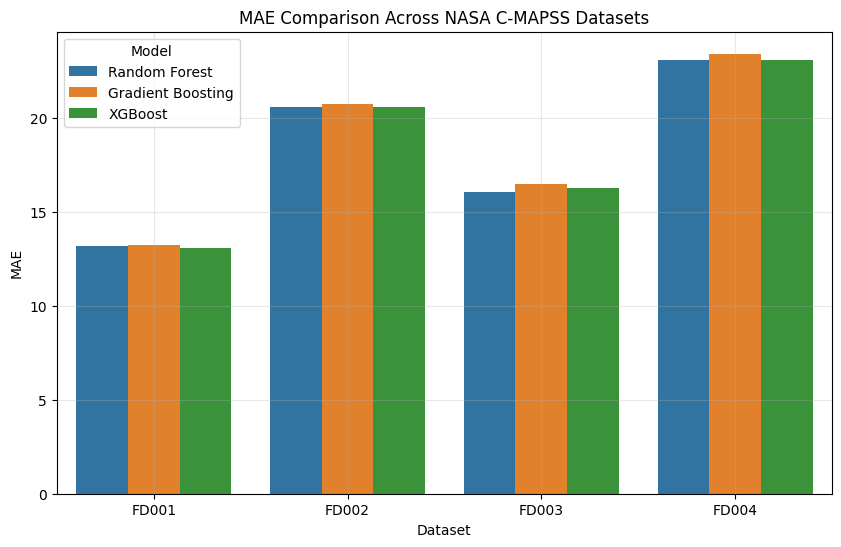

In [ ]:
# ============================================
# MAE Comparison
# ============================================

plt.figure(figsize=(10,6))

sns.barplot(

    data=comparison,

    x="Dataset",

    y="MAE",

    hue="Model"

)

plt.title("MAE Comparison Across NASA C-MAPSS Datasets")

plt.grid(alpha=0.3)

plt.show()

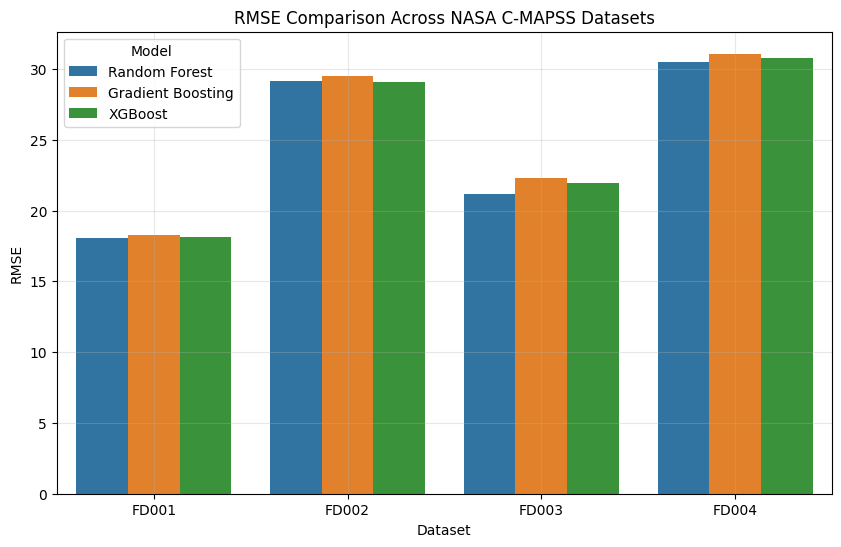

In [ ]:
# ============================================
# RMSE Comparison
# ============================================

plt.figure(figsize=(10,6))

sns.barplot(

    data=comparison,

    x="Dataset",

    y="RMSE",

    hue="Model"

)

plt.title("RMSE Comparison Across NASA C-MAPSS Datasets")

plt.grid(alpha=0.3)

plt.show()

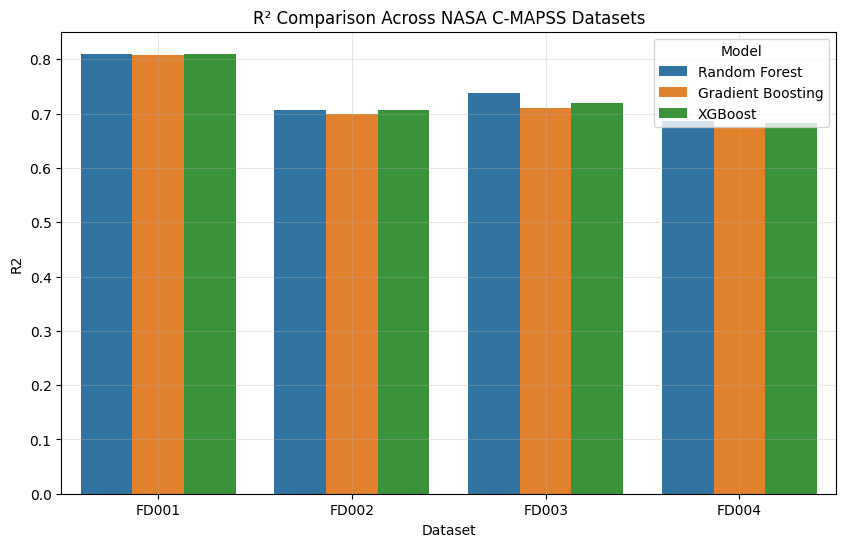

In [ ]:
# ============================================
# R² Comparison
# ============================================

plt.figure(figsize=(10,6))

sns.barplot(

    data=comparison,

    x="Dataset",

    y="R2",

    hue="Model"

)

plt.title("R² Comparison Across NASA C-MAPSS Datasets")

plt.grid(alpha=0.3)

plt.show()

In [ ]:
# ============================================
# Average Performance
# ============================================

overall = comparison.groupby("Model")[

    ["MAE","RMSE","R2"]

].mean()

overall.sort_values(

    by="RMSE"

)

,MAE,RMSE,R2
Model,,,
Random Forest,18.236463,24.731260,0.735470
XGBoost,18.250126,24.980068,0.729460
Gradient Boosting,18.485699,25.276876,0.722883


In [ ]:
# ============================================
# Feature Importance (Random Forest)
# ============================================

best_rf = trained_models["FD001"]["Random Forest"]["model"]

importance = pd.DataFrame({

    "Feature": selected_features,

    "Importance": best_rf.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance

,Feature,Importance
9,sensor_11,0.584590
8,sensor_9,0.129300
5,sensor_4,0.069497
10,sensor_12,0.043705
6,sensor_7,0.025451
12,sensor_14,0.024497
13,sensor_15,0.020145
16,sensor_21,0.015944
3,sensor_2,0.014837
4,sensor_3,0.014451


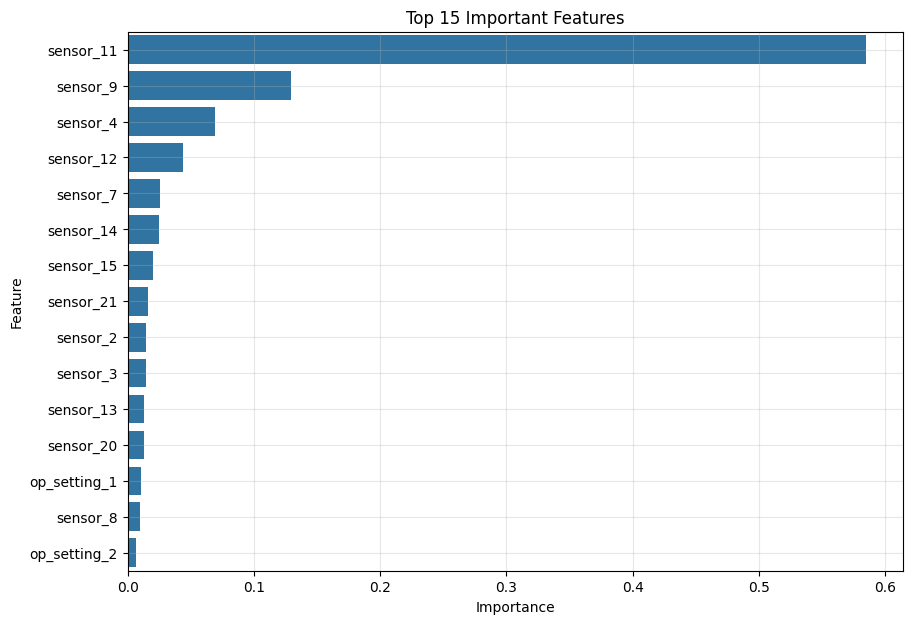

In [ ]:
# ============================================
# Top Important Sensors
# ============================================

plt.figure(figsize=(10,7))

sns.barplot(

    data=importance.head(15),

    x="Importance",

    y="Feature"

)

plt.title("Top 15 Important Features")

plt.grid(alpha=0.3)

plt.show()

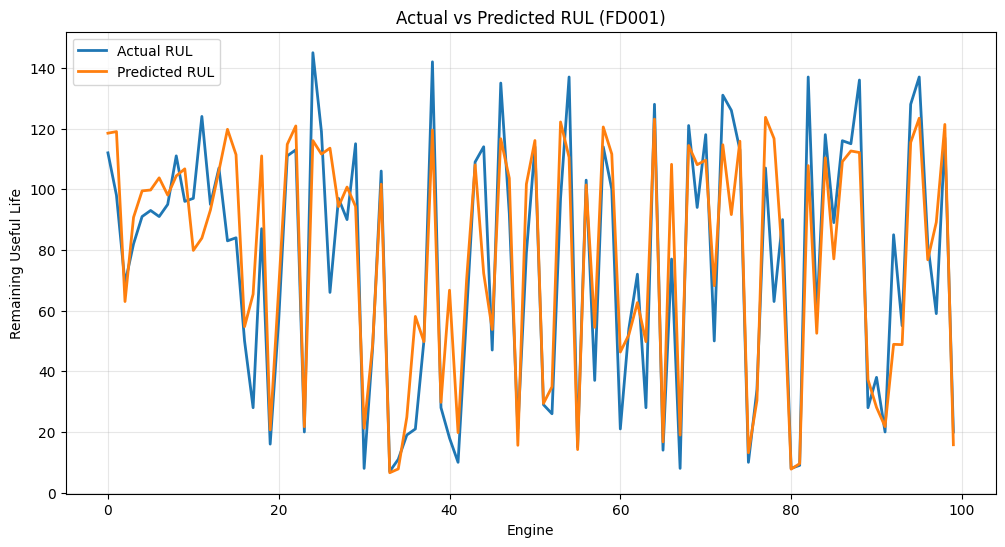

In [ ]:
# ============================================
# Prediction vs Actual
# ============================================

prediction = trained_models["FD001"]["Random Forest"]["prediction"]

actual = true_rul["FD001"]

plt.figure(figsize=(12,6))

plt.plot(

    actual,

    label="Actual RUL",

    linewidth=2

)

plt.plot(

    prediction,

    label="Predicted RUL",

    linewidth=2

)

plt.legend()

plt.title("Actual vs Predicted RUL (FD001)")

plt.xlabel("Engine")

plt.ylabel("Remaining Useful Life")

plt.grid(alpha=0.3)

plt.show()

In [ ]:
# ============================================
# Dynamic Health Score
# ============================================

def health_score(rul):

    if rul >= 110:
        return 100

    elif rul >= 80:
        return 80

    elif rul >= 50:
        return 60

    elif rul >= 25:
        return 40

    else:
        return 20

health = [health_score(x) for x in prediction]

pd.Series(health).value_counts()

,count
100,29
80,25
60,18
20,16
40,12


In [ ]:
# ============================================
# Failure Probability
# ============================================

failure = [

    100-h

    for h in health

]

failure[:10]

[0, 0, 40, 20, 20, 20, 20, 20, 20, 20]

In [ ]:
recommendation = []

for h in health:

    if h == 100:
        recommendation.append("Healthy")

    elif h == 80:
        recommendation.append("Inspection Required")

    elif h == 60:
        recommendation.append("Maintenance Required")

    else:
        recommendation.append("Immediate Maintenance")

pd.Series(recommendation).value_counts()

,count
Healthy,29
Immediate Maintenance,28
Inspection Required,25
Maintenance Required,18


In [ ]:
# ============================================
# Final Dashboard
# ============================================

dashboard=pd.DataFrame({

    "Actual_RUL":actual,

    "Predicted_RUL":prediction,

    "Health_Score":health,

    "Failure_Probability":failure,

    "Recommendation":recommendation

})

dashboard.head(20)

,Actual_RUL,Predicted_RUL,Health_Score,Failure_Probability,Recommendation
0,112,118.482406,100,0,Healthy
1,98,118.996363,100,0,Healthy
2,69,62.994637,60,40,Maintenance Required
3,82,90.739818,80,20,Inspection Required
4,91,99.454058,80,20,Inspection Required
5,93,99.757577,80,20,Inspection Required
6,91,103.754974,80,20,Inspection Required
7,95,98.072221,80,20,Inspection Required
8,111,104.385723,80,20,Inspection Required
9,96,106.727385,80,20,Inspection Required


In [ ]:
print(pd.Series(prediction).describe())

count    100.000000
mean      78.027562
std       37.862465
min        6.568266
25%       48.872847
50%       92.389423
75%      111.446466
max      123.698609
dtype: float64


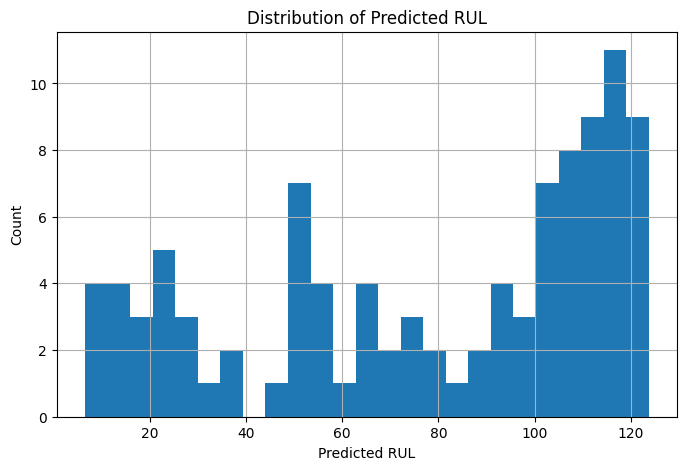

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(prediction, bins=25)

plt.title("Distribution of Predicted RUL")

plt.xlabel("Predicted RUL")

plt.ylabel("Count")

plt.grid(True)

plt.show()

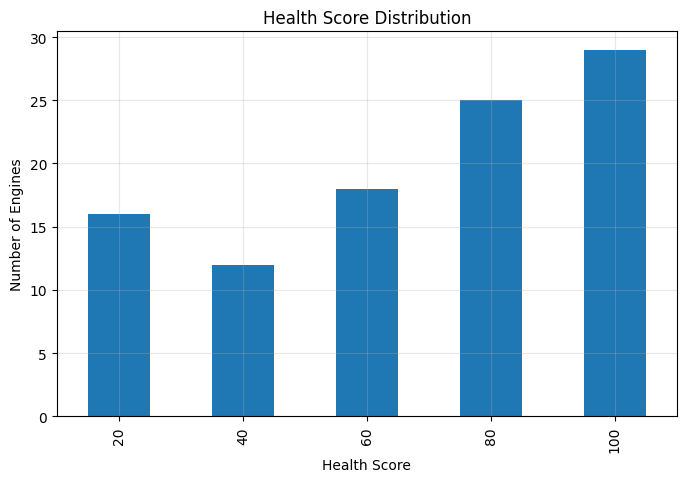

In [ ]:
# ============================================
# Health Score Distribution
# ============================================

plt.figure(figsize=(8,5))

pd.Series(health).value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Health Score Distribution")

plt.xlabel("Health Score")

plt.ylabel("Number of Engines")

plt.grid(alpha=0.3)

plt.show()

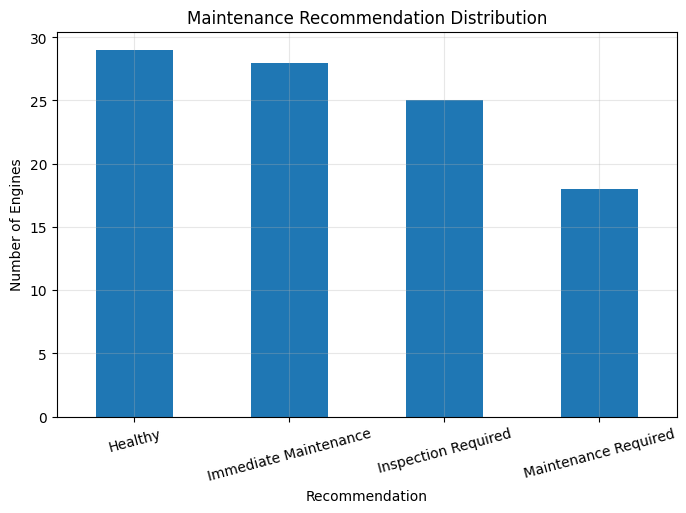

In [ ]:
# ============================================
# Recommendation Distribution
# ============================================

plt.figure(figsize=(8,5))

pd.Series(recommendation).value_counts().plot(
    kind="bar"
)

plt.title("Maintenance Recommendation Distribution")

plt.xlabel("Recommendation")

plt.ylabel("Number of Engines")

plt.xticks(rotation=15)

plt.grid(alpha=0.3)

plt.show()

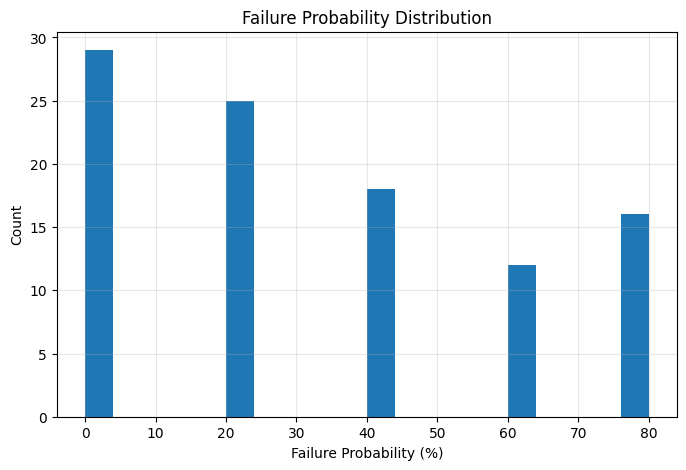

In [ ]:
# ============================================
# Failure Probability Distribution
# ============================================

plt.figure(figsize=(8,5))

plt.hist(failure, bins=20)

plt.title("Failure Probability Distribution")

plt.xlabel("Failure Probability (%)")

plt.ylabel("Count")

plt.grid(alpha=0.3)

plt.show()

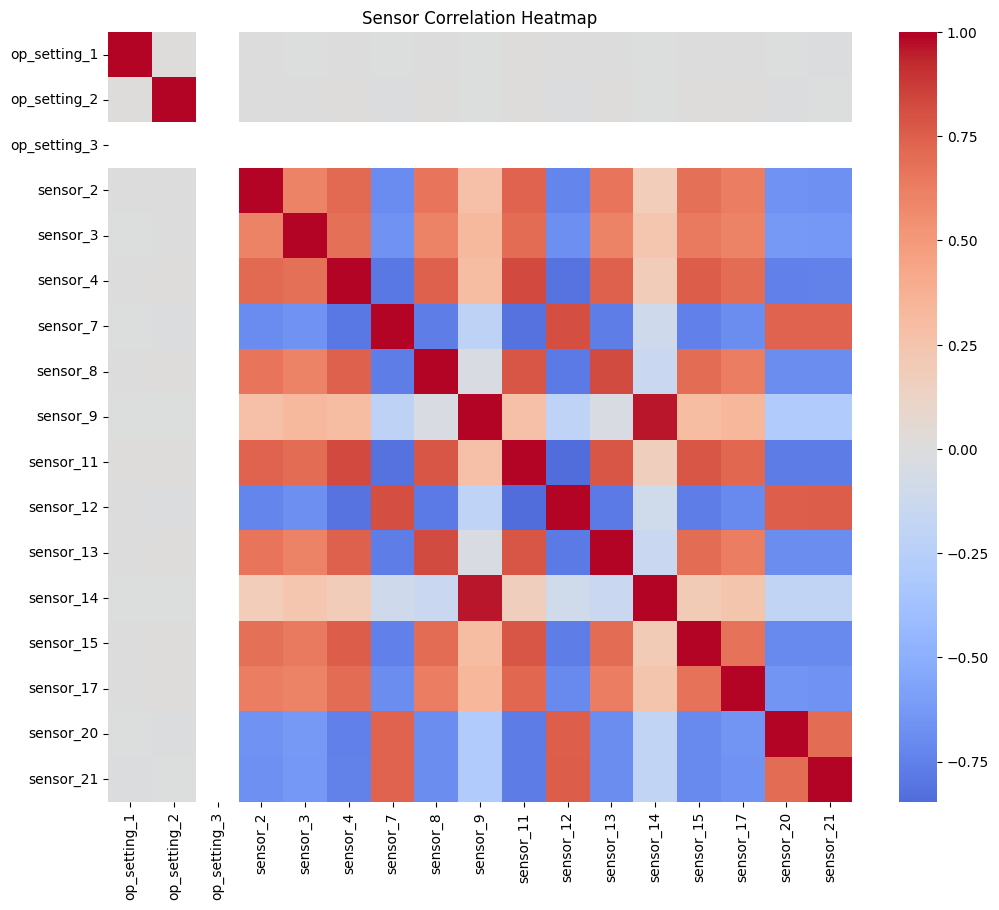

In [ ]:
# ============================================
# Correlation Heatmap
# ============================================

corr = datasets["FD001"]["train"][selected_features].corr()

plt.figure(figsize=(12,10))

sns.heatmap(

    corr,

    cmap="coolwarm",

    center=0

)

plt.title("Sensor Correlation Heatmap")

plt.show()

In [ ]:
# ============================================
# Final Summary
# ============================================

print("="*60)

print("NASA C-MAPSS Predictive Maintenance Summary")

print("="*60)

print()

print("Best Models")

print(best_models)

print()

print("Overall Performance")

print(overall)

print()

print("Dashboard Shape :", dashboard.shape)

NASA C-MAPSS Predictive Maintenance Summary

Best Models
  Dataset          Model        MAE       RMSE        R2
0   FD001  Random Forest  13.164105  18.095250  0.810386
1   FD002        XGBoost  20.565353  29.090670  0.707393
2   FD003  Random Forest  16.083574  21.180206  0.738211
3   FD004  Random Forest  23.100669  30.517750  0.686720

Overall Performance
                         MAE       RMSE        R2
Model                                            
Gradient Boosting  18.485699  25.276876  0.722883
Random Forest      18.236463  24.731260  0.735470
XGBoost            18.250126  24.980068  0.729460

Dashboard Shape : (100, 5)


In [ ]:
# ============================================
# Save Results
# ============================================

comparison.to_csv(

    "Model_Comparison.csv",

    index=False

)

dashboard.to_csv(

    "Engine_Health_Dashboard.csv",

    index=False

)

importance.to_csv(

    "Feature_Importance.csv",

    index=False

)

best_models.to_csv(

    "Best_Model.csv",

    index=False

)

print("All CSV Files Saved Successfully")

All CSV Files Saved Successfully


In [ ]:
from google.colab import files

files.download("Model_Comparison.csv")

files.download("Engine_Health_Dashboard.csv")

files.download("Feature_Importance.csv")

files.download("Best_Model.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================
# Hyperparameter Tuning Libraries
# ============================================

from sklearn.model_selection import RandomizedSearchCV

print("RandomizedSearchCV Imported")

RandomizedSearchCV Imported


In [ ]:
# ============================================
# Random Forest Parameter Grid
# ============================================

rf_params = {

    "n_estimators":[100,200,300,500],

    "max_depth":[10,15,20,None],

    "min_samples_split":[2,5,10],

    "min_samples_leaf":[1,2,4],

    "max_features":["sqrt","log2"]

}

print(rf_params)

{'n_estimators': [100, 200, 300, 500], 'max_depth': [10, 15, 20, None], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'max_features': ['sqrt', 'log2']}


In [ ]:
# ============================================
# Random Forest Hyperparameter Tuning
# ============================================

rf_search = RandomizedSearchCV(

    estimator=RandomForestRegressor(random_state=42),

    param_distributions=rf_params,

    n_iter=15,

    scoring="neg_root_mean_squared_error",

    cv=3,

    verbose=2,

    random_state=42,

    n_jobs=-1

)

rf_search.fit(

    scaled_data["FD001"]["X"],

    scaled_data["FD001"]["y"]

)

print("Best Parameters")

print(rf_search.best_params_)

print()

print("Best Score")

print(rf_search.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best Parameters
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': None}

Best Score
-18.45515994615469


In [ ]:
best_rf = rf_search.best_estimator_

print(best_rf)

RandomForestRegressor(max_features='log2', min_samples_leaf=4, n_estimators=500,
                      random_state=42)


In [ ]:
# ============================================
# Cross Validation
# ============================================

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(

    best_rf,

    scaled_data["FD001"]["X"],

    scaled_data["FD001"]["y"],

    cv=5,

    scoring="r2",

    n_jobs=-1

)

print("Cross Validation Scores")

print(cv_scores)

print()

print("Average CV Score")

print(cv_scores.mean())

Cross Validation Scores
[0.85900218 0.79219991 0.80345593 0.78184225 0.78451621]

Average CV Score
0.8042032977651518


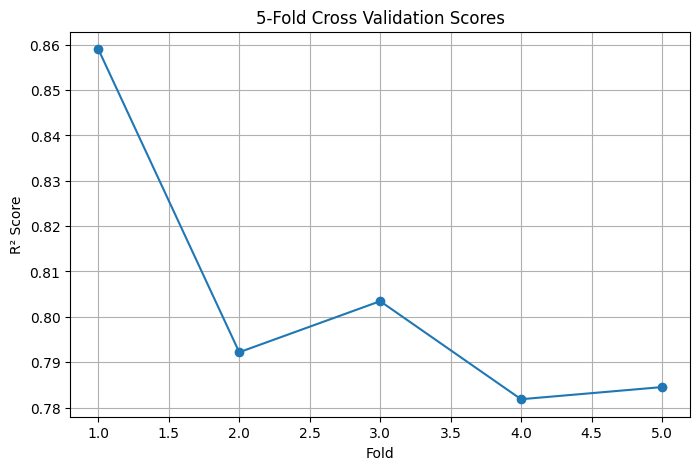

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(

    range(1,6),

    cv_scores,

    marker="o"

)

plt.title("5-Fold Cross Validation Scores")

plt.xlabel("Fold")

plt.ylabel("R² Score")

plt.grid(True)

plt.show()

In [ ]:
import joblib

joblib.dump(

    best_rf,

    "Best_RF_Model.pkl"

)

print("Best RF Saved")

Best RF Saved


In [ ]:
# ============================================
# Install SHAP
# ============================================

!pip install shap -q

In [ ]:
# ============================================
# Import SHAP
# ============================================

import shap

print("SHAP Imported Successfully")

SHAP Imported Successfully


In [ ]:
# ============================================
# SHAP Explainer
# ============================================

explainer = shap.TreeExplainer(best_rf)

shap_values = explainer.shap_values(

    scaled_data["FD001"]["X"][:500]

)

print("SHAP Values Generated")

SHAP Values Generated


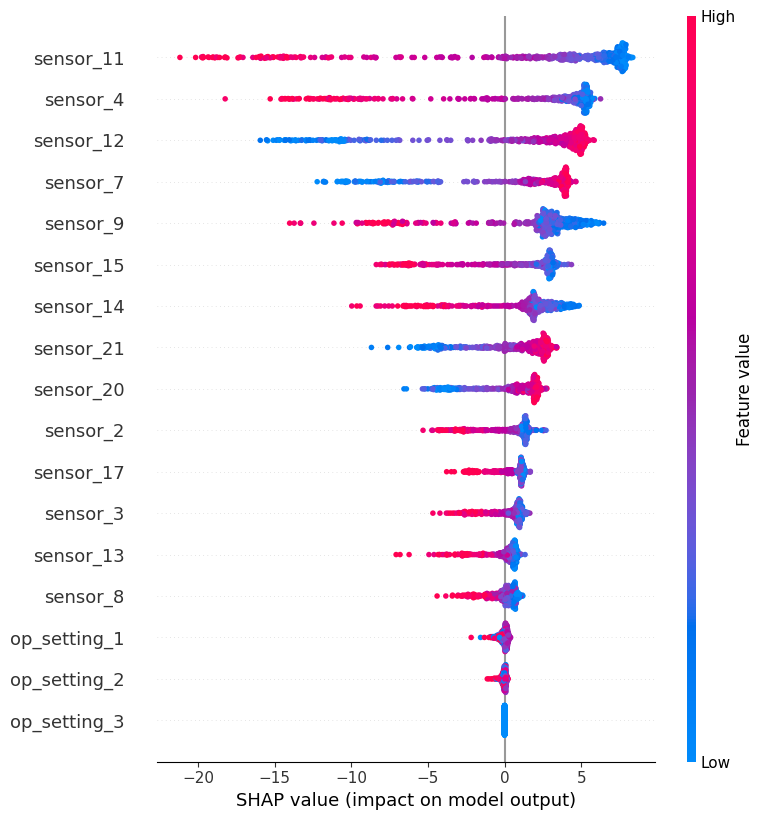

In [ ]:
# ============================================
# SHAP Summary Plot
# ============================================

shap.summary_plot(

    shap_values,

    scaled_data["FD001"]["X"][:500],

    feature_names=selected_features

)

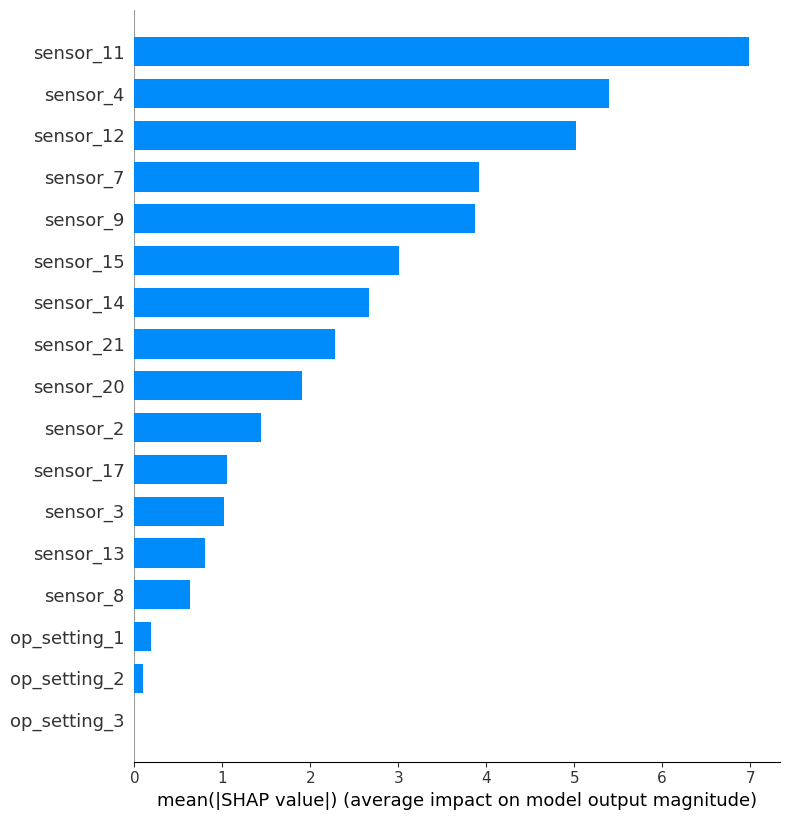

In [ ]:
# ============================================
# SHAP Feature Importance
# ============================================

shap.summary_plot(

    shap_values,

    scaled_data["FD001"]["X"][:500],

    feature_names=selected_features,

    plot_type="bar"

)

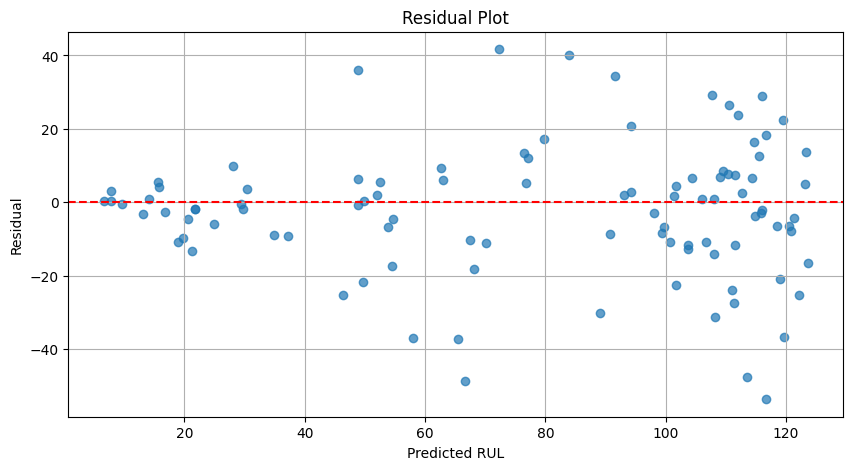

In [ ]:
# ============================================
# Residual Analysis
# ============================================

residual = actual - prediction

plt.figure(figsize=(10,5))

plt.scatter(

    prediction,

    residual,

    alpha=0.7

)

plt.axhline(

    y=0,

    color="red",

    linestyle="--"

)

plt.xlabel("Predicted RUL")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.grid(True)

plt.show()

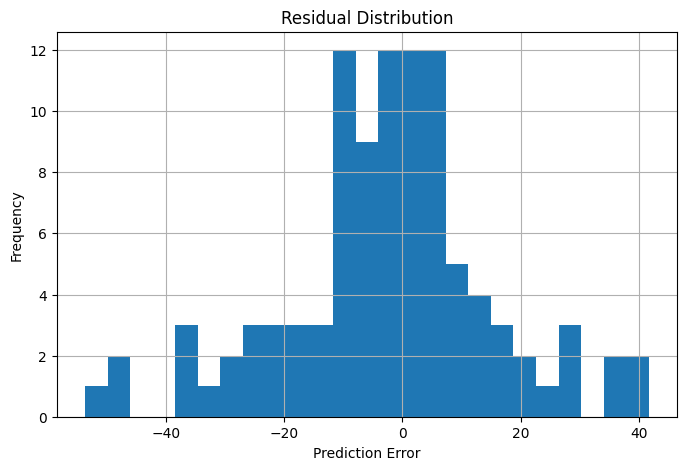

In [ ]:
# ============================================
# Error Distribution
# ============================================

plt.figure(figsize=(8,5))

plt.hist(

    residual,

    bins=25

)

plt.title("Residual Distribution")

plt.xlabel("Prediction Error")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

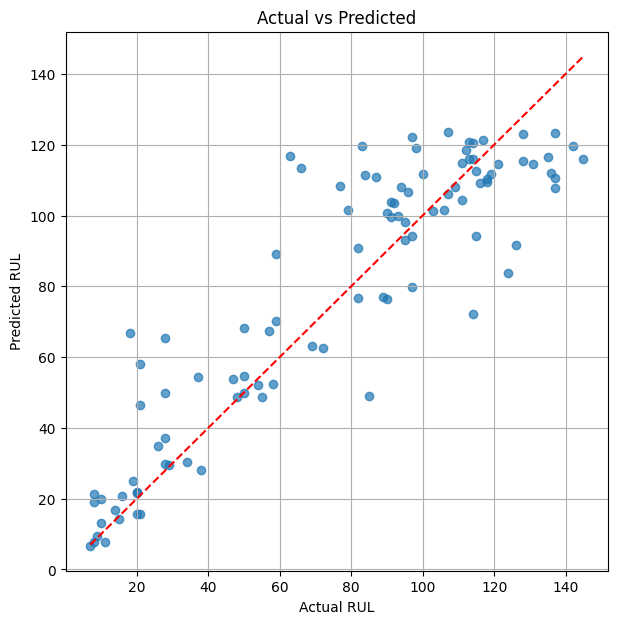

In [ ]:
# ============================================
# Actual vs Predicted
# ============================================

plt.figure(figsize=(7,7))

plt.scatter(

    actual,

    prediction,

    alpha=0.7

)

plt.plot(

    [actual.min(), actual.max()],

    [actual.min(), actual.max()],

    color="red",

    linestyle="--"

)

plt.xlabel("Actual RUL")

plt.ylabel("Predicted RUL")

plt.title("Actual vs Predicted")

plt.grid(True)

plt.show()